<a href="https://colab.research.google.com/github/thaissanchesroque/Projetos/blob/main/Profissao_Cientista_de_Dados_M14_Pratique_resolvido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Base utilizada: **CHURN_TELECON_MOD08_TAREFA.csv**.

Objetivo: aplicar limpeza, verificação de tipos, tratamento de dados ausentes e correção de inconsistências em uma base de churn de telecomunicações.

## Importação das bibliotecas e leitura da base

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
df = pd.read_csv('/CHURN_TELECON_MOD08_TAREFA.csv', delimiter=';')

df.head(10)

# O erro FileNotFoundError indica que o arquivo 'CHURN_TELECON_MOD08_TAREFA.csv' não foi encontrado.
# Por favor, certifique-se de que o arquivo foi carregado para o ambiente do Colab antes de tentar lê-lo.

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


In [59]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Legenda dos dados

* **customerID**: ID único de cada cliente.
* **Genero**: gênero do cliente.
* **Idoso**: indica se o cliente tem acima de 60 anos.
* **Casado**: indica se o cliente é casado.
* **Dependents**: indica se o cliente possui dependentes.
* **Tempo_como_Cliente**: tempo em meses como cliente.
* **PhoneService**: indica se contratou serviço telefônico.
* **Servico_Internet**: tipo de serviço de internet contratado.
* **Servico_Seguranca**: indica se contratou serviço de segurança.
* **Suporte_Tecnico**: indica se já acionou suporte técnico.
* **StreamingTV**: indica se contratou streaming de TV.
* **Tipo_Contrato**: tipo de contrato.
* **PaymentMethod**: forma de pagamento.
* **Pagamento_Mensal**: valor pago mensalmente.
* **Total_Pago**: valor total pago pelo cliente.
* **Churn**: indica se o cliente abandonou ou não o serviço.

# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          2500 non-null   object 
 1   Genero              2488 non-null   object 
 2   Idoso               2500 non-null   int64  
 3   Casado              2500 non-null   object 
 4   Dependents          2500 non-null   object 
 5   Tempo_como_Cliente  2500 non-null   int64  
 6   PhoneService        1018 non-null   object 
 7   Servico_Internet    2500 non-null   object 
 8   Servico_Seguranca   2500 non-null   object 
 9   Suporte_Tecnico     2500 non-null   object 
 10  StreamingTV         2500 non-null   object 
 11  Tipo_Contrato       2500 non-null   object 
 12  PaymentMethod       2500 non-null   object 
 13  Pagamento_Mensal    2175 non-null   float64
 14  Total_Pago          2500 non-null   float64
 15  Churn               2495 non-null   object 
dtypes: flo

**Análise dos tipos de dados:**

A maior parte das colunas está coerente com o esperado. As colunas de texto aparecem como `object`, e as colunas numéricas aparecem como `int64` ou `float64`.

A coluna **Churn** representa se o cliente abandonou ou não o serviço. Como ela será a variável principal de previsão em um modelo futuro, faz sentido transformá-la em formato numérico: `0` para cliente que não abandonou e `1` para cliente que abandonou.

Os valores ausentes serão tratados nas próximas etapas, então a conversão será feita preservando os valores nulos.

In [61]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1}).astype('Int64')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          2500 non-null   object 
 1   Genero              2488 non-null   object 
 2   Idoso               2500 non-null   int64  
 3   Casado              2500 non-null   object 
 4   Dependents          2500 non-null   object 
 5   Tempo_como_Cliente  2500 non-null   int64  
 6   PhoneService        1018 non-null   object 
 7   Servico_Internet    2500 non-null   object 
 8   Servico_Seguranca   2500 non-null   object 
 9   Suporte_Tecnico     2500 non-null   object 
 10  StreamingTV         2500 non-null   object 
 11  Tipo_Contrato       2500 non-null   object 
 12  PaymentMethod       2500 non-null   object 
 13  Pagamento_Mensal    2175 non-null   float64
 14  Total_Pago          2500 non-null   float64
 15  Churn               2495 non-null   Int64  
dtypes: Int

# 2 - Esse exercício faremos por etapas

## A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [62]:
def formato_percentual(valor):
    return f'{valor:.2f}%'.replace('.', ',')

faltantes = pd.DataFrame({
    'Quantidade de Ausentes': df.isnull().sum(),
    'Percentual de Ausentes': (df.isnull().sum() / len(df)) * 100
})

faltantes = faltantes[faltantes['Quantidade de Ausentes'] > 0]
faltantes = faltantes.sort_values(by='Percentual de Ausentes', ascending=False)

faltantes.style.format({
    'Percentual de Ausentes': formato_percentual
})

,Quantidade de Ausentes,Percentual de Ausentes
PhoneService,1482,"59,28%"
Pagamento_Mensal,325,"13,00%"
Genero,12,"0,48%"
Churn,5,"0,20%"


**Análise:**

Existem valores ausentes nas colunas **PhoneService**, **Pagamento_Mensal**, **Genero** e **Churn**.

A coluna **PhoneService** possui o maior percentual de dados ausentes. A coluna **Pagamento_Mensal** também possui uma quantidade relevante de valores faltantes. Já **Genero** e **Churn** possuem percentuais pequenos de ausência.

## B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

In [63]:
linhas_antes = df.shape[0]

df.dropna(subset=['Genero', 'Churn'], inplace=True)
df.reset_index(drop=True, inplace=True)

linhas_depois = df.shape[0]
linhas_removidas = linhas_antes - linhas_depois

print(f'Linhas antes da exclusão: {linhas_antes}')
print(f'Linhas depois da exclusão: {linhas_depois}')
print(f'Linhas removidas: {linhas_removidas}')

Linhas antes da exclusão: 2500
Linhas depois da exclusão: 2488
Linhas removidas: 12


**Justificativa:**

As linhas com valores ausentes em **Genero** foram excluídas porque a quantidade de dados faltantes era pequena em relação ao tamanho da base. Nesse caso, a exclusão não causa perda relevante de informação.

As linhas com valores ausentes em **Churn** também foram excluídas porque essa é a variável principal do problema. Como o objetivo futuro é prever abandono de clientes, não faz sentido manter registros em que não sabemos se o cliente abandonou ou não o serviço.

In [64]:
faltantes_apos_exclusao = pd.DataFrame({
    'Quantidade de Ausentes': df.isnull().sum(),
    'Percentual de Ausentes': (df.isnull().sum() / len(df)) * 100
})

faltantes_apos_exclusao = faltantes_apos_exclusao[faltantes_apos_exclusao['Quantidade de Ausentes'] > 0]
faltantes_apos_exclusao = faltantes_apos_exclusao.sort_values(by='Percentual de Ausentes', ascending=False)

faltantes_apos_exclusao.style.format({
    'Percentual de Ausentes': formato_percentual
})

,Quantidade de Ausentes,Percentual de Ausentes
PhoneService,1482,"59,57%"
Pagamento_Mensal,313,"12,58%"


## C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

**Dica variáveis numéricas:** verifique distribuição, média e mediana.

**Dica variáveis categóricas:** verifique o valor que mais aparece e utilize a moda quando fizer sentido.

In [65]:
df['Pagamento_Mensal'].describe()

,Pagamento_Mensal
count,2175.000000
mean,65.607563
std,29.931520
min,18.400000
25%,39.500000
50%,71.450000
75%,90.250000
max,118.650000


In [66]:
media_pagamento = df['Pagamento_Mensal'].mean()
mediana_pagamento = df['Pagamento_Mensal'].median()

print(f'Média do Pagamento Mensal: {media_pagamento:.2f}')
print(f'Mediana do Pagamento Mensal: {mediana_pagamento:.2f}')

Média do Pagamento Mensal: 65.61
Mediana do Pagamento Mensal: 71.45


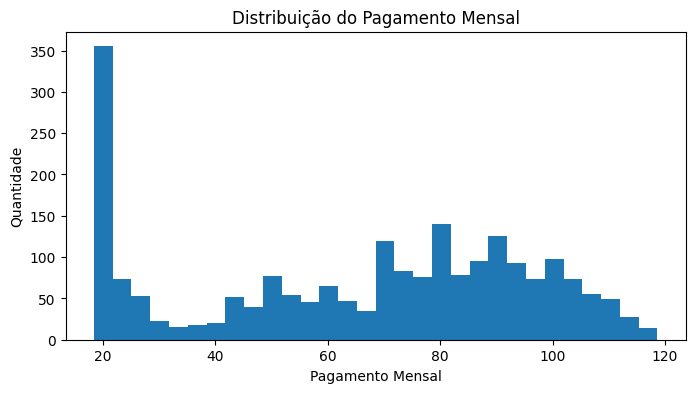

In [67]:
plt.figure(figsize=(8, 4))
plt.hist(df['Pagamento_Mensal'].dropna(), bins=30)
plt.title('Distribuição do Pagamento Mensal')
plt.xlabel('Pagamento Mensal')
plt.ylabel('Quantidade')
plt.show()

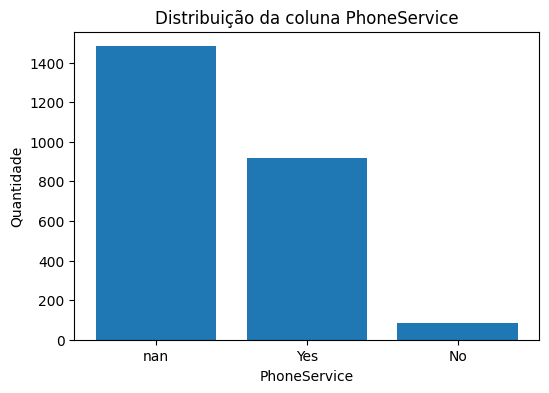

In [68]:
contagem_phone = df['PhoneService'].value_counts(dropna=False)

plt.figure(figsize=(6, 4))
plt.bar(contagem_phone.index.astype(str), contagem_phone.values)
plt.title('Distribuição da coluna PhoneService')
plt.xlabel('PhoneService')
plt.ylabel('Quantidade')
plt.show()

In [69]:
mediana_pagamento = df['Pagamento_Mensal'].median()
moda_phone_service = df['PhoneService'].mode()[0]

df['Pagamento_Mensal'].fillna(mediana_pagamento, inplace=True)
df['PhoneService'].fillna(moda_phone_service, inplace=True)

print(f'Valor usado para preencher Pagamento_Mensal: {mediana_pagamento}')
print(f'Valor usado para preencher PhoneService: {moda_phone_service}')

Valor usado para preencher Pagamento_Mensal: 71.45
Valor usado para preencher PhoneService: Yes


/tmp/ipykernel_1644/2257982928.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Pagamento_Mensal'].fillna(mediana_pagamento, inplace=True)
/tmp/ipykernel_1644/2257982928.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

**Justificativa:**

A coluna **Pagamento_Mensal** é numérica. Como existe diferença entre média e mediana e a distribuição não é perfeitamente simétrica, foi escolhida a **mediana**, pois ela é menos sensível a valores extremos.

A coluna **PhoneService** é categórica. Por isso, foi utilizada a **moda**, ou seja, o valor que mais aparece na coluna. Essa escolha mantém o padrão mais frequente da base.

In [70]:
df.isnull().sum()

,0
customerID,0
Genero,0
Idoso,0
Casado,0
Dependents,0
Tempo_como_Cliente,0
PhoneService,0
Servico_Internet,0
Servico_Seguranca,0
Suporte_Tecnico,0


# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiúsculas ou minúsculas, ou até mesmo mesmos valores porém escritos de forma diferente e corrija.

In [71]:
colunas_categoricas = df.select_dtypes(include='object').columns
colunas_categoricas = [coluna for coluna in colunas_categoricas if coluna != 'customerID']

for coluna in colunas_categoricas:
    print(f'\nColuna: {coluna}')
    print(df[coluna].value_counts())


Coluna: Genero
Genero
Male      1265
Female    1212
M            4
f            4
F            3
Name: count, dtype: int64

Coluna: Casado
Casado
No     1262
Yes    1226
Name: count, dtype: int64

Coluna: Dependents
Dependents
No     1705
Yes     783
Name: count, dtype: int64

Coluna: PhoneService
PhoneService
Yes    2402
No       86
Name: count, dtype: int64

Coluna: Servico_Internet
Servico_Internet
Fiber optic    1119
DSL             835
No              527
dsl               7
Name: count, dtype: int64

Coluna: Servico_Seguranca
Servico_Seguranca
No                     1254
Yes                     707
No internet service     527
Name: count, dtype: int64

Coluna: Suporte_Tecnico
Suporte_Tecnico
No                     1250
Yes                     711
No internet service     527
Name: count, dtype: int64

Coluna: StreamingTV
StreamingTV
No                     1001
Yes                     960
No internet service     527
Name: count, dtype: int64

Coluna: Tipo_Contrato
Tipo_Contrato
Mo

**Análise:**

Foram encontrados valores escritos de formas diferentes em algumas colunas categóricas.

Na coluna **Genero**, aparecem valores como `M`, `F` e `f`, que representam o mesmo sentido de `Male` e `Female`.

Na coluna **Servico_Internet**, aparece `dsl` em minúsculo, que representa o mesmo valor de `DSL`.

Esses valores precisam ser padronizados para evitar que o Python entenda a mesma categoria como categorias diferentes.

In [72]:
df['Genero'] = df['Genero'].replace({
    'M': 'Male',
    'F': 'Female',
    'f': 'Female'
})

df['Servico_Internet'] = df['Servico_Internet'].replace({
    'dsl': 'DSL'
})

In [73]:
for coluna in ['Genero', 'Servico_Internet']:
    print(f'\nColuna: {coluna}')
    print(df[coluna].value_counts())


Coluna: Genero
Genero
Male      1269
Female    1219
Name: count, dtype: int64

Coluna: Servico_Internet
Servico_Internet
Fiber optic    1119
DSL             842
No              527
Name: count, dtype: int64


**Justificativa:**

A correção foi feita para padronizar categorias que tinham o mesmo significado, mas estavam escritas de formas diferentes. Isso evita erro na análise e também evita que um modelo futuro trate valores iguais como se fossem categorias diferentes.

# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

In [74]:
df_padronizado = df.rename(columns={
    'customerID': 'ID_Cliente',
    'PhoneService': 'Servico_Telefonico',
    'PaymentMethod': 'Metodo_Pagamento'
})

df_padronizado.head()

,ID_Cliente,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,Servico_Telefonico,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,Metodo_Pagamento,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),71.45,1840.75,0
4,8191-XWSZG,Female,0,No,No,52,Yes,No,No internet service,No internet service,No internet service,One year,Mailed check,71.45,1022.95,0


**Conclusão:**

Nesta atividade, a base foi preparada para uma futura etapa de modelagem. Primeiro, os tipos de dados foram verificados e a coluna **Churn** foi transformada para formato numérico. Depois, os dados ausentes foram analisados por quantidade e percentual.

As linhas com poucos dados faltantes em **Genero** e **Churn** foram removidas. Já os valores ausentes em **Pagamento_Mensal** e **PhoneService** foram substituídos, respectivamente, pela mediana e pela moda.

Por fim, foram corrigidos valores categóricos escritos de formas diferentes, como `M`, `F`, `f` e `dsl`. Esse tratamento deixa a base mais limpa, mais consistente e mais adequada para análise e machine learning.